In [6]:
import sys
import glob
import os
import pandas as pd
import numpy as np

import re

import seaborn as sns
import matplotlib.pyplot as plt


## run getIKIstats

In [7]:
IKIstat = getIKIstats(Verbose = 0)

################### ENJA15
################### BML12
################### AR22
################### SG12
################### KTHJ08
################### RUC17


In [6]:
pd.set_option('display.max_columns', None)

STATdf = pd.DataFrame(IKIstat)
STATdfT = STATdf.T


STATdfT.shape
#STATdfT[['QBW', 'QWW']].corr()

(353, 8)

In [7]:
print(STATdfT[['KBI2','PUB3', 'BW_PUB2']].corr())

#STATdfT.groupby('lng')[['QBW3','QBW', 'QWW2', 'QWW', 'QtotWW_KBI', 'KBI2','PUB3', 'BW_PUB', 'BW_PUB2']].corr()

STATdfT.groupby('lng')[['KBI2','PUB3', 'BW_PUB2']].corr()


             KBI2      PUB3   BW_PUB2
KBI2     1.000000  0.564436  0.408147
PUB3     0.564436  1.000000  0.181618
BW_PUB2  0.408147  0.181618  1.000000


KBI2      PUB3   BW_PUB2
lng                                      
ar  KBI2     1.000000  0.250167  0.454514
    PUB3     0.250167  1.000000  0.254325
    BW_PUB2  0.454514  0.254325  1.000000
da  KBI2     1.000000  0.373938  0.538701
    PUB3     0.373938  1.000000  0.375722
    BW_PUB2  0.538701  0.375722  1.000000
de  KBI2     1.000000  0.741370  0.532256
    PUB3     0.741370  1.000000  0.567846
    BW_PUB2  0.532256  0.567846  1.000000
es  KBI2     1.000000  0.594889  0.553081
    PUB3     0.594889  1.000000  0.554606
    BW_PUB2  0.553081  0.554606  1.000000
ja  KBI2     1.000000  0.487327  0.335990
    PUB3     0.487327  1.000000  0.601872
    BW_PUB2  0.335990  0.601872  1.000000
zh  KBI2     1.000000  0.403456  0.347627
    PUB3     0.403456  1.000000  0.838208
    BW_PUB2  0.347627  0.838208  1.000000

In [94]:

# ratio of WW chars in text/ BW chars in text and WW chars in process / BW chars in process
STATdfT['BW2_PUB'] = STATdfT['BW_PUB'] * 2
STATdfT['PP'] = (STATdfT['WWchars'] * STATdfT['NumBW']) / (STATdfT['BWchars'] * STATdfT['NumWW'])
STATdfT['BW3_PUB'] = STATdfT['BW_PUB'] / STATdfT['PP']

STATdfT[STATdfT.lng == 'de'].head(10) 

,lng,study,edits,words,chars,BWchars,WWchars,BWratio,BW_PUB,BW_PUB2,KBI2,PUB3,KBI,PUB,NumBW,NumWW,NumTot,QNumBW,QNumWW,QtotBW,QtotWW,QtotWW_KBI,QBW,QWW,QBW3,QWW2,LogKBI,LogPUB,BW2_PUB,PP,BW3_PUB
SG12_P01_T1,de,SG12,1582,148,859,148,711,0,218,421,218,375,109,125,159.0,924,1396,0.853186,0.146814,0.886103,0.338109,94,0.504298,0.393983,0.898997,0.818768,4.700480,4.836282,436,0.826672,263.708091
SG12_P01_T2,de,SG12,1595,161,919,161,758,0,234,530,218,330,109,110,171.5,940,1445,0.845704,0.154296,0.881315,0.349481,94,0.483737,0.415917,0.86782,0.8,4.700480,4.709530,468,0.858973,272.418287
SG12_P02_T3,de,SG12,1473,165,914,165,749,0,359,780,280,654,140,218,159.0,901,1396,0.85,0.15,0.886103,0.354585,140,0.665473,0.340258,0.895415,0.76361,4.948760,5.389072,718,0.80107,448.150868
SG12_P02_T4,de,SG12,1094,109,702,109,593,0,406,702,282,609,141,203,108.0,698,1025,0.866005,0.133995,0.894634,0.319024,125,0.64878,0.399024,0.902439,0.77561,4.955827,5.318120,812,0.841776,482.313597
SG12_P03_T5,de,SG12,1064,139,740,139,601,0,265,726,250,606,125,202,115.0,697,1017,0.858374,0.141626,0.886922,0.314651,109,0.721731,0.376598,0.899705,0.791544,4.836282,5.313206,530,0.713386,371.467771
SG12_P03_T6,de,SG12,1240,113,724,113,611,0,288,803,220,468,110,156,108.0,769,1100,0.876853,0.123147,0.901818,0.300909,94,0.593636,0.385455,0.890909,0.817273,4.709530,5.056246,576,0.759382,379.255865
SG12_P04_T1,de,SG12,1261,151,793,151,642,0,375,827,312,726,156,242,148.0,752,1199,0.835556,0.164444,0.876564,0.372811,141,0.701418,0.393661,0.895746,0.768974,5.056246,5.493061,750,0.836762,448.1561
SG12_P04_T2,de,SG12,1631,154,884,154,730,0,359,852,312,606,156,202,155.0,950,1509,0.859729,0.140271,0.897283,0.370444,140,0.645461,0.419483,0.89397,0.793903,5.056246,5.313206,718,0.773411,464.17764
SG12_P05_T3,de,SG12,1361,152,863,152,711,0,530,1956,312,936,156,312,148.0,849,1234,0.851555,0.148445,0.880065,0.311994,140,0.733387,0.371961,0.877634,0.733387,5.056246,5.746203,1060,0.815418,649.973771
SG12_P05_T4,de,SG12,1243,109,692,109,583,0,608,2357,312,1029,156,343,111.0,749,1064,0.87093,0.12907,0.895677,0.296053,140,0.756579,0.343045,0.880639,0.730263,5.056246,5.840642,1216,0.792653,767.044149


## plot

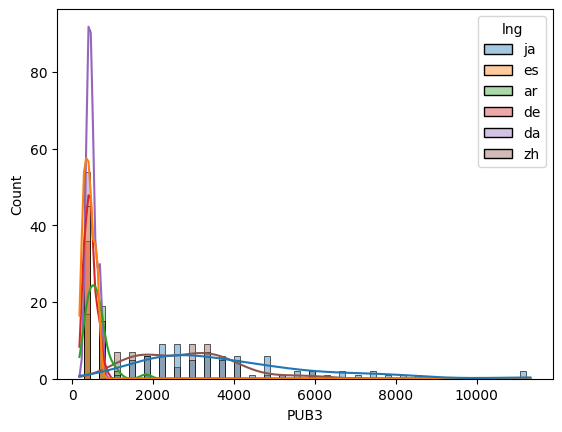

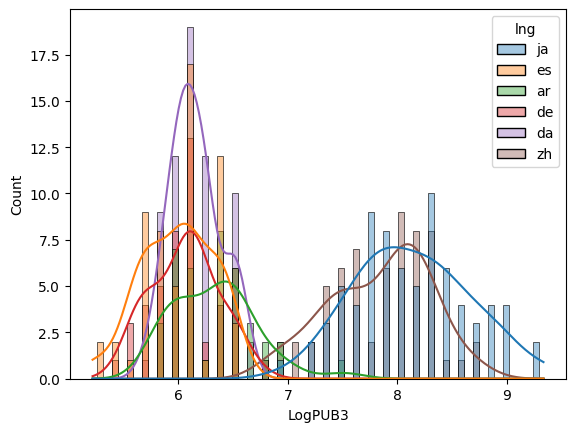

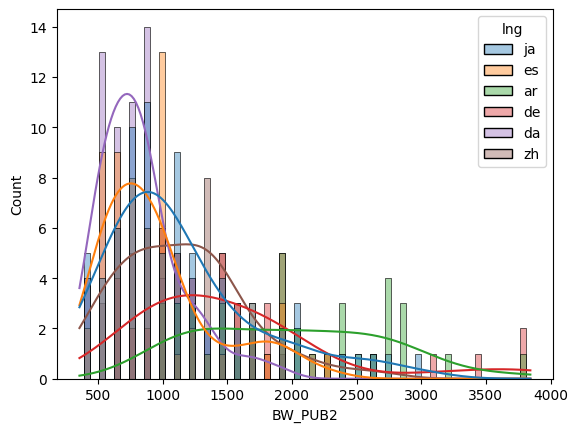

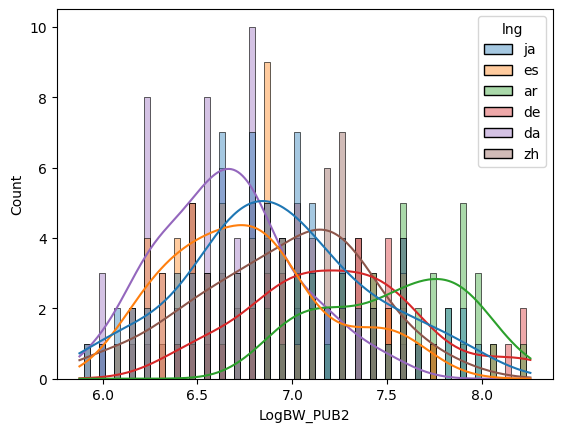

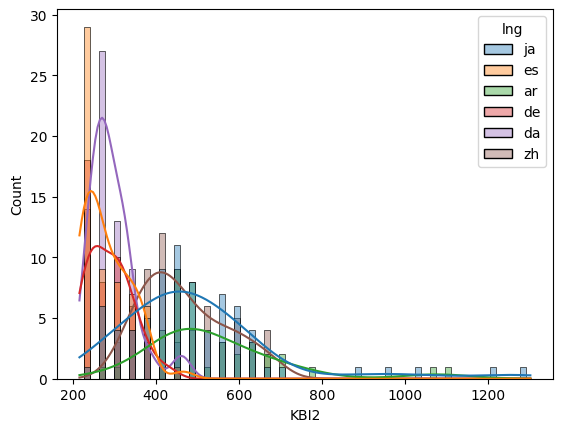

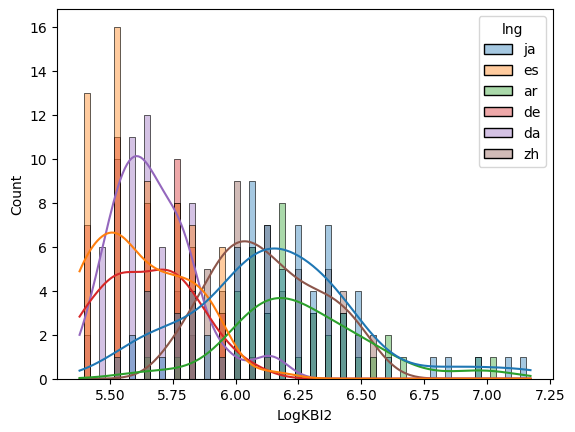

In [8]:
STATdfT.head()
STATdfT['LogKBI2'] = np.log(STATdfT['KBI2'].astype(int)+1)
#STATdfT['LogQ_KBI'] = np.log(STATdfT['Q_KBI'].astype(int)+1)
STATdfT['LogPUB3'] = np.log(STATdfT['PUB3'].astype(int)+1)
STATdfT['LogBW_PUB2'] = np.log(STATdfT['BW_PUB2'].astype(int)+1)

sns.histplot(data=STATdfT, x='PUB3', kde=True, hue='lng',  shrink=0.4, alpha=0.4, bins=30)
plt.show()
sns.histplot(data=STATdfT, x='LogPUB3', kde=True, hue='lng',  shrink=0.4, alpha=0.4, bins=30)
plt.show()
sns.histplot(data=STATdfT, x='BW_PUB2', kde=True, hue='lng',  shrink=0.4, alpha=0.4, bins=30)
plt.show()
sns.histplot(data=STATdfT, x='LogBW_PUB2', kde=True, hue='lng',  shrink=0.4, alpha=0.4, bins=30)
plt.show()
sns.histplot(data=STATdfT, x='KBI2', kde=True, hue='lng',  shrink=0.4, alpha=0.4, bins=30)
plt.show()
sns.histplot(data=STATdfT, x='LogKBI2', kde=True, hue='lng',  shrink=0.4, alpha=0.4, bins=30)
plt.show()
#sns.histplot(data=STATdfT, x='Q_KBI', kde=True, hue='lng',  shrink=0.4, alpha=0.4, bins=30)
#plt.show()
#sns.histplot(data=STATdfT, x='LogQ_KBI', kde=True, hue='lng',  shrink=0.4, alpha=0.4, bins=30)


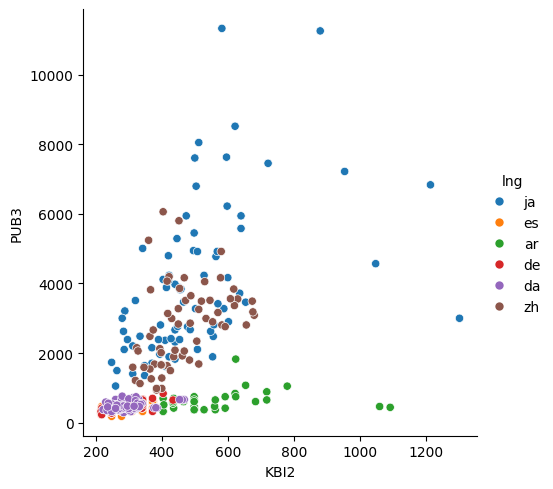

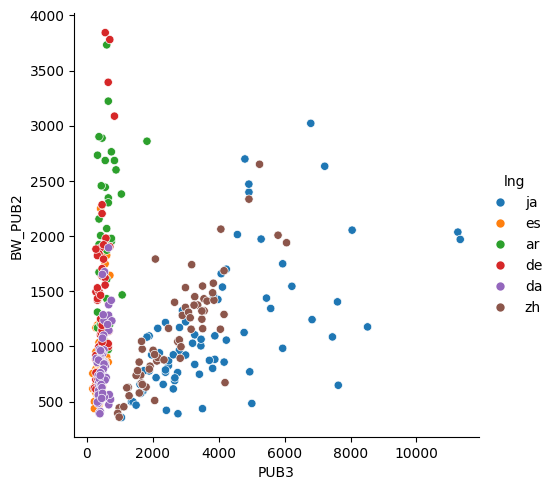

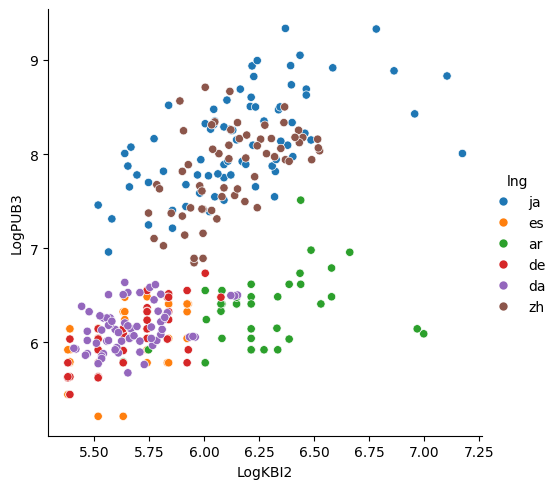

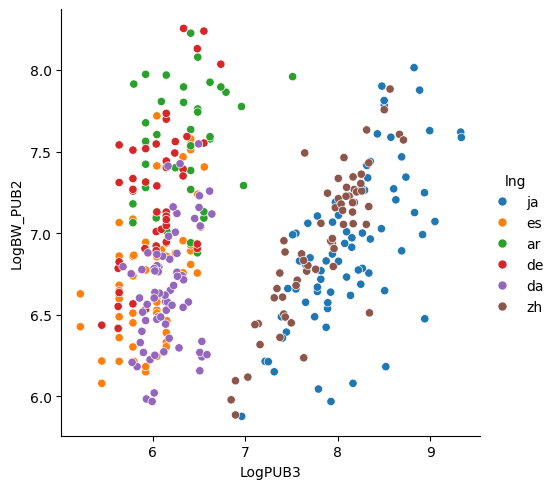

In [264]:

#sns.relplot(data=STATdfT, x='KBI', y='PUB', hue='lng')
#plt.show()
sns.relplot(data=STATdfT, x='KBI2', y='PUB3', hue='lng')
plt.show()
#sns.relplot(data=STATdfT, x='LogKBI2', y='LogPUB3', hue='lng')
#plt.show()
sns.relplot(data=STATdfT, x='PUB3', y='BW_PUB2', hue='lng')
plt.show()
sns.relplot(data=STATdfT, x='LogKBI2', y='LogPUB3', hue='lng')
plt.show()
sns.relplot(data=STATdfT, x='LogPUB3', y='LogBW_PUB2', hue='lng')
plt.show()


## test

In [257]:
pd.set_option('display.max_columns', None)

fn = '/data/critt/tprdb/TPRDB/ENJA15/Tables/P01_T1.kd'
fn = '/data/critt/tprdb/TPRDB/BML12/Tables/P01_T1.kd'
#fn = '/data/critt/tprdb/TPRDB/SG12/Tables/P01_T1.kd'
#fn = '/data/critt/tprdb/TPRDB/NJ12/Tables/P16_T4.kd'
#fn = '/data/critt/tprdb/TPRDB/RUC17/Tables/P01_T1.kd'

df = pd.read_csv(fn, sep='\t')

# compute char-bigrams
df['BI'] = df['Char'] +  df['Char'].shift(-1)
df['BI'] = df['BI'].astype(str)

df['Dur'] = df['Dur'].replace(0, 1)
df['Strokes'] = df['Strokes'].replace(0, 1)

# shift dur for Chinese
#df['NextDur'] = df['Dur'].shift(-1).fillna(0)
#df['NextDur'] = df['NextDur'].astype(int)

# shift type
df['NextType'] = df['Type'].shift(-1).fillna(df['Type'])

# shift row to become IKI
df['IKI'] = df['Pause'].shift(-1).fillna(df["Pause"]) 
df['IKI'] = df['IKI'] - df['Dur'].shift(-1).fillna(df['IKI'])

df['Border'] = 'XX'
WW = []
BW = []
last_index = df.index[-1]
for index, row in df.iterrows():
    if (index == last_index) : break

    Border = 'XX'
    if re.match(r"__", row.BI):  Border = df.loc[index, 'Border'] = 'SS'
    elif re.match(r"_[^_]", row.BI): Border = df.loc[index, 'Border'] = 'SW'
    elif re.match(r"[^_]_", row.BI): Border = df.loc[index, 'Border'] = 'WS'
    elif re.match(r"[^_][^_]", row.BI): Border = df.loc[index, 'Border'] = 'WW'
        
    if ((row.Type != 'Mins') or (row.NextType != 'Mins')) : continue

    if((df.TL.iloc[0] == 'zh') or (df.TL.iloc[0] == 'ja')) :
        WW.extend([row.Dur / row.Strokes] * row.Strokes)
#        WW.append(row.IKI)
#        WW.append(row.Dur / row.Strokes)
        BW.append(row.IKI)
    else :
        if(Border == 'WW') : WW.append(row.IKI)
#        if(Border == 'WS') : BW.append(row.IKI)
        if(Border == 'SW') : BW.append(row.IKI)

# count number of chars and words in the final text
chars = 0
tt = pd.read_csv(fn.replace('.kd', '.tt') , sep='\t')
for index, row in tt.iterrows():
    chars += len(row.TToken)
#    print(row.TToken)
    
words = len(tt)

df['Q3'] = 1- (words / chars)
df['Q2'] = (chars-words) / (chars)
df['Q4'] = Q4 = np.mean(df.IKI < 3* np.median(BW))
df['Q5'] = np.mean(df.IKI < 2 * np.median(WW))

df['PUB4'] = int(np.quantile(df.IKI, Q4))
wl = chars / words
cl = 3
df['PUB5'] = int(np.quantile(df.IKI, 1 - (1 / (wl * cl))))

df['PUB2'] = int(np.quantile(df.IKI, (chars-(words/2.5)) / (chars)))

df['KBI'] = 2 * int(np.median(WW))
df['PUB'] = 3 * int(np.median(BW))

print(f"c:{chars} w:{words} wl:{chars/words:.2f} Q:{(chars-(words/2)) / (chars):.3f}\tlen WW:{len(WW)} len BW:{len(BW)}\t", end = '')
print(f"PP:{(len(WW) * words)/(len(BW) * chars):.3f}\tQKBI:{np.mean(df.IKI <df['KBI']):.3f} QPUB:{np.mean(df.IKI < df['PUB']):.3f} ")

df.head()


c:801 w:181 wl:4.43 Q:0.887	len WW:721 len BW:186	PP:0.876	QKBI:0.808 QPUB:0.890 


,Id,Study,Session,SL,TL,Task,Text,Part,Time,Pause,Border,Type,Cur,Char,TTseg,STid,SGid,TTid,Strokes,Dur,EdStr,LsDist,Draft,DistCur,DistTTid,BI,NextType,IKI,Q3,Q2,Q4,Q5,PUB4,PUB5,PUB2,KBI,PUB
0,1,BML12,P01_T1,en,es,T,1,P01,92016,92016,WW,Mins,0,E,1,2,2,1,1,1,0,0,0,1,0,El,Mins,155.0,0.774032,0.774032,0.890454,0.807512,454,683,577,248,465
1,2,BML12,P01_T1,en,es,T,1,P01,92172,156,WS,Mins,1,l,1,2,2,1,1,1,0,0,0,1,0,l_,Mins,140.0,0.774032,0.774032,0.890454,0.807512,454,683,577,248,465
2,3,BML12,P01_T1,en,es,T,1,P01,92313,141,SW,Mins,2,_,1,2,2,1,1,1,0,0,0,1,1,_e,Mins,61.0,0.774032,0.774032,0.890454,0.807512,454,683,577,248,465
3,4,BML12,P01_T1,en,es,T,1,P01,92375,62,WW,Mins,3,e,1,2,2,2,1,1,0,0,0,1,0,en,Mins,187.0,0.774032,0.774032,0.890454,0.807512,454,683,577,248,465
4,5,BML12,P01_T1,en,es,T,1,P01,92563,188,WW,Mins,4,n,1,2,2,2,1,1,0,0,0,1,0,nf,Mins,264.0,0.774032,0.774032,0.890454,0.807512,454,683,577,248,465


In [192]:
df[['PUB2',	'KBI', 'PUB']].head()

,PUB2,KBI,PUB
0,1075,370,1707
1,1075,370,1707
2,1075,370,1707
3,1075,370,1707
4,1075,370,1707


## getIKIstats

In [4]:

def getIKIstats(Verbose = 1) :
    # this is the path on the CRITT server
    path = "/data/critt/tprdb/TPRDB"
    
    # Studies are expected to contain a 'Translog-II' folder which contains the XML log files
    # the function creates a parallel 'SessionProps' folder and file structure with 
    studies=[
            'ACS08', 'ADU17', 'AE17', 'AR22', 'ARMT19', 'ATJA22', 'ATZH22', 'AU20', 
            'BACK2020', 'BB17', 'BD08', 'BD13', 'BITEXT_07092023', 
             'BML12', 'BML12_MT_SA', 'BML12_MT_SI', 'BML12_MT_SM', 'BML12_NTO_SA', 'BML12_NTO_SI', 'BML12_NTO_SM', 'BML12_re', 'BML12_SA', 'BML12_SI', 'BML12_SM', 
             'CET6', 'CPH17', 'CREATIVE', 'CREATIVE2', 'CS19', 'DG01', 'DG21', 'DG21error', 
              'ENDU20', 'ENDU20-MT', 'ENJA15', 'ENTP19', 'ESMT19', 'GS12', 'GV18', 
             'HE17', 'HF12', 'HLR13', 'HNUJd', 'HNUJml', 'HNUJms', 'IMBi18', 'IMBi18bolt', 'IMBst18', 'IMBst18bolt', 
             'JAMT19', 'JIN15', 'JLG10', 'JTD16', 'KTHJ08', 'lecontra', 'LiTian2019New', 'LWB09', 
             'MAecho2019', 'MP16', 'MPM16', 'MS12', 'MS13', 'NFC25', 'NEUROTRAD_3', 'NJ12', 'OCT13',  
             'predict20', 'predict20-MT', 'RH12', 'RUC16', 'RUC17', 'RUCMT17', 
             'SG12', 'SJM16', 'SPC15', 'ST19', 'STC17', 'STC17bolt', 'STML18', 'STML18bolt', 'TDA14', 'WARDHA13', 'XIANG19', 'ZHMT19', 'ZHPT12'
    ]
    
    
    studies = ['RUC17', 'BML12','AR22','SG12','DG21', 'NJ12', 'KTHJ08']
    studies = ['ENJA15', 'BML12','AR22','SG12', 'KTHJ08', 'RUC17']

    IKIstats = {}

    for study in studies:
        if(study == 'RUC17') :
            files = glob.glob(f"/data/critt/tprdb/TEST/{study}/Tables/*.kd")
        else :
            files = glob.glob(f"{path}/{study}/Tables/*.kd")
            
        print(f"################### {study}")
    
        for fn in sorted(files):
            
            if('_T' not in fn) : continue
            
            if(Verbose) : print(f"{fn}")
            IKI_medians(fn, IKIstats)
    
            ######################################################
    return IKIstats     


## compute medians

In [3]:
def IKI_medians(session, H, Verbose = 1):
  
    df = pd.read_csv(session, sep='\t')

    df['BI'] = df['Char'] +  df['Char'].shift(-1).fillna('_')
    df['BI'] = df['BI'].astype(str)
    

    # shift dur for Chinese
    df['Strokes'] = df['Strokes'].replace(0, 1)
    df['Dur'] = df['Dur'].replace(0, 1)
    
    # shift row to become IKI
    df['IKI'] = df['Pause'].shift(-1).fillna(df['Pause'])
    df['IKI'] = df['IKI'] - df['Dur'].shift(-1).fillna(df['Dur'])

    # shift type
    df['NextType'] = df['Type'].shift(-1).fillna(df['Type'])
    
    chunk_length = 3

    df['Border'] = 'XX'
    WW = [] # within Word IKI
    BW = [] # between Word IKI
    edits = 0
    last_index = df.index[-1]
    for index, row in df.iterrows():
        if (index == last_index) : break
    
        if('Strokes' in row) : edits += row.Strokes
        else: edits += 1
            
        Border = 'XX'
        if re.match(r"__", row.BI):  Border = df.loc[index, 'Border'] = 'SS'
        elif re.match(r"_[^_]", row.BI): Border = df.loc[index, 'Border'] = 'SW'
        elif re.match(r"[^_]_", row.BI): Border = df.loc[index, 'Border'] = 'WS'
        elif re.match(r"[^_][^_]", row.BI): Border = df.loc[index, 'Border'] = 'WW'
            
        if (row.Type != 'Mins' or row.NextType != 'Mins') : continue
    
        if((df.TL.iloc[0] == 'zh') or (df.TL.iloc[0] == 'ja')) :
            WW.extend([row.Dur / row.Strokes] * row.Strokes)
            BW.append(row.IKI)
            chunk_length = 1.5

        else :
            if(Border == 'WW') : WW.append(row.IKI)
            if(Border == 'WS') : BW.append(row.IKI)
#            if(Border == 'SW') : BW.append(row.IKI)
    
    
 
    # count number of chars and words in the final text
    chars = 0
    tt = pd.read_csv(session.replace('.kd', '.tt') , sep='\t')
    for index, row in tt.iterrows():
        chars += len(row.TToken)        
    words = len(tt)


    SS = df['Study'].iloc[0] + '_' + df['Session'].iloc[0]

    H.setdefault(SS, {})
    
    H[SS]['lng'] = df['TL'].iloc[0]
    H[SS]['study'] = df['Study'].iloc[0]
    H[SS]['edits'] = edits
    
#    H[SS]['words'] = words
#    H[SS]['chars'] = chars

    wl = chars/ words 
    H[SS]['BW_PUB2'] = int(np.quantile(df.IKI, 1 - (1 / (wl * chunk_length))))
    H[SS]['Q_PUB2'] = 1 - (1 / (wl * chunk_length))

    H[SS]['KBI2'] = 2 * int(np.median(WW))
    H[SS]['PUB3'] = 3 * int(np.median(BW))
#    H[SS]['KBI'] = int(np.median(WW))
#    H[SS]['PUB'] = int(np.median(BW))

    '''
    H[SS]['NumBW'] = len(BW) /2
    H[SS]['NumWW'] = len(WW)
    H[SS]['NumTot'] = len(df)

    
    H[SS]['QNumBW'] = 1 - (H[SS]['NumBW']) / (H[SS]['NumWW'] + H[SS]['NumBW']) 
    H[SS]['QNumWW'] = 1 - (H[SS]['NumWW']) / (H[SS]['NumWW'] + H[SS]['NumBW']) 
    H[SS]['QtotBW'] = 1 - (H[SS]['NumBW']) / (H[SS]['NumTot']) 
    H[SS]['QtotWW'] = 1 - (H[SS]['NumWW']) / (H[SS]['NumTot']) 
    '''
    
#    H[SS]['QtotWW_KBI2'] = 2 * int(np.quantile(df.IKI, H[SS]['QtotWW']))
#    H[SS]['Q_KBI'] = 2 * int(np.quantile(df.IKI, len(WW) / len(df)))

    # quantile of PUB
#    df['Q'] = df['IKI'] < H[SS]['PUB']
#    H[SS]['QBW'] = df['Q'].mean()
    
    # quantile of KBI
#    df['Q'] = df['IKI'] < H[SS]['KBI']
#    H[SS]['QWW'] = df['Q'].mean()

    # quantile of PUB
    df['Q'] = df['IKI'] < H[SS]['PUB3']
    H[SS]['QBW3'] = df['Q'].mean()
    
    # quantile of KBI
    df['Q'] = df['IKI'] < H[SS]['KBI2']
    H[SS]['QWW2'] = df['Q'].mean()

    return H
